In [1]:
pip install pandas matplotlib seaborn openpyxl


===== DATASET INFO =====

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None

===== FIRST 5 ROWS =====

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM

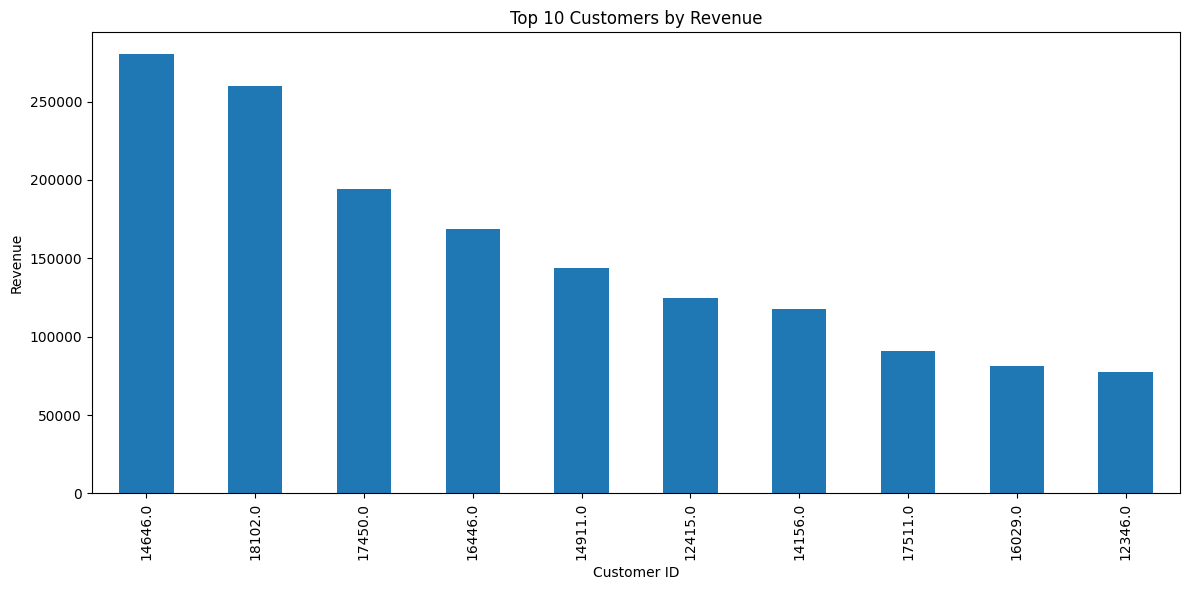

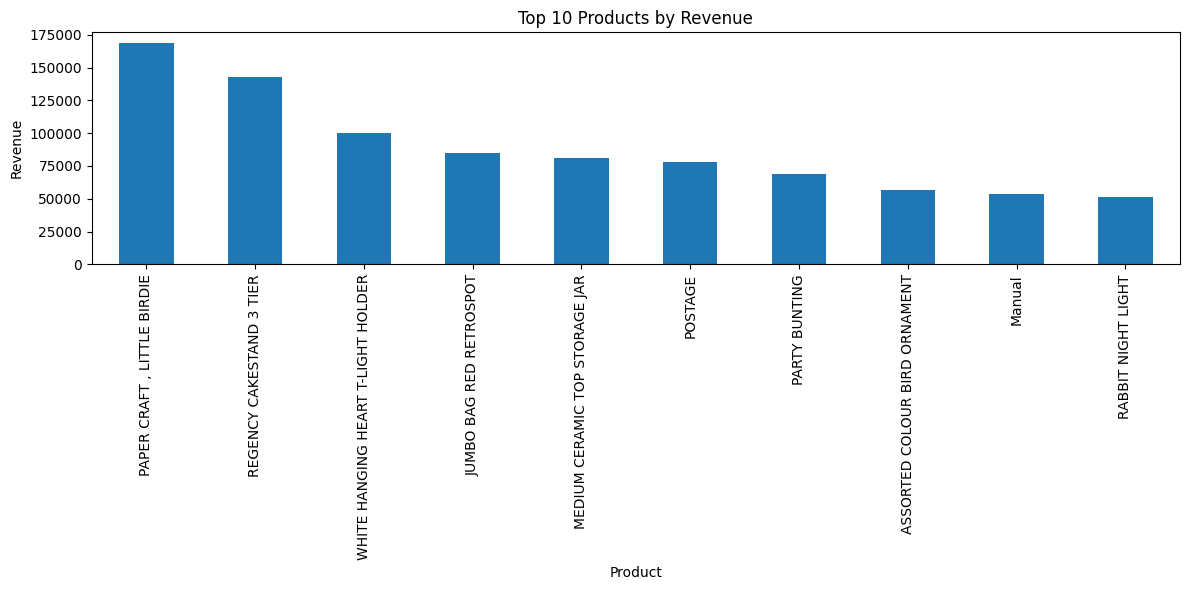

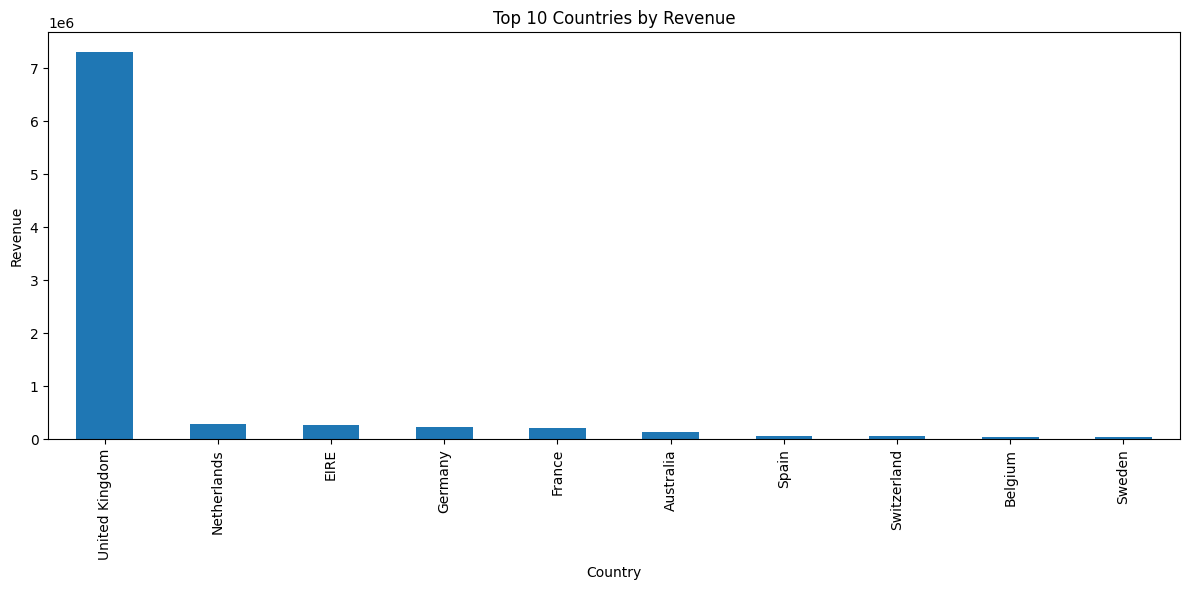

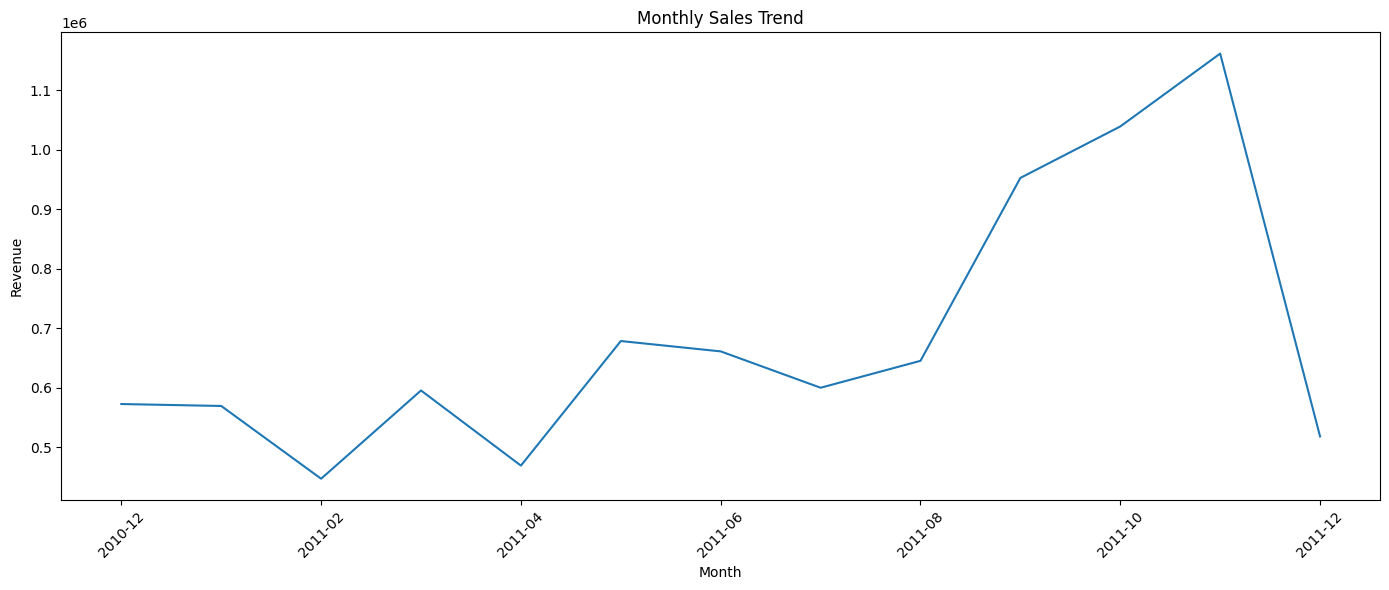

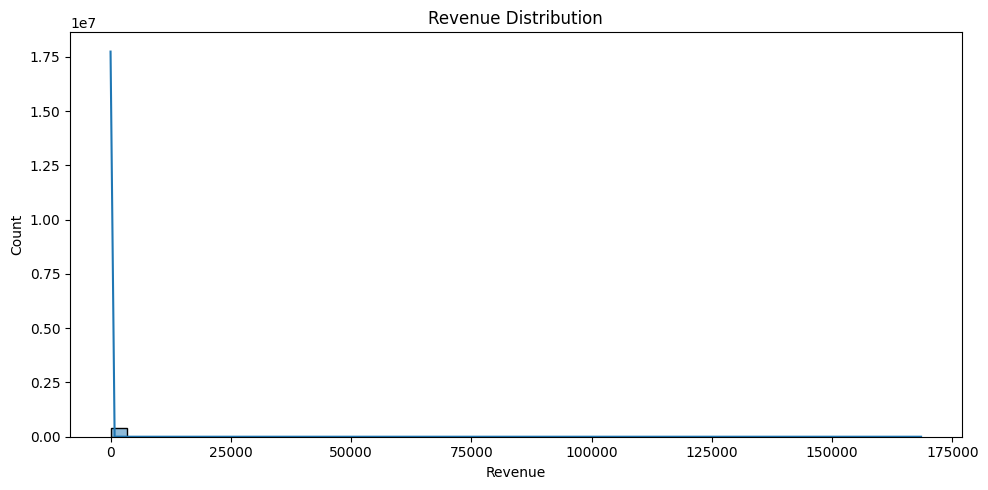

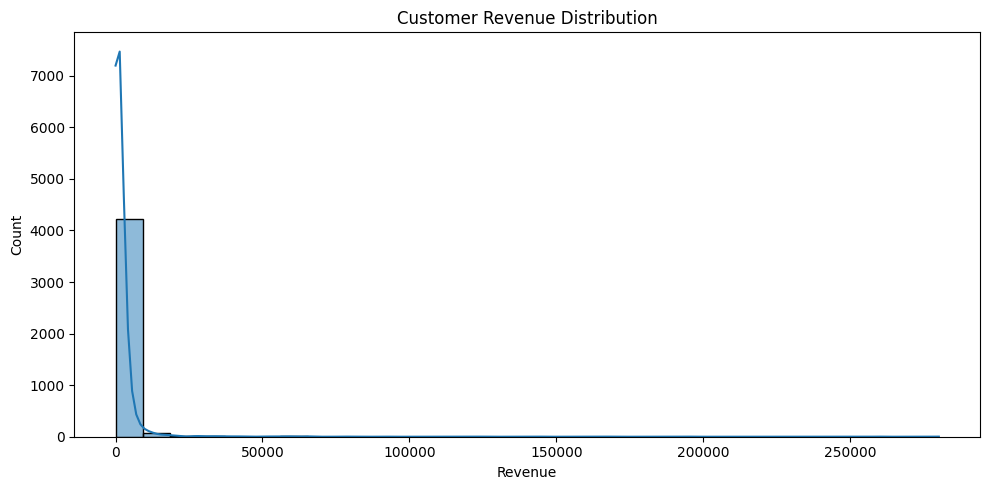

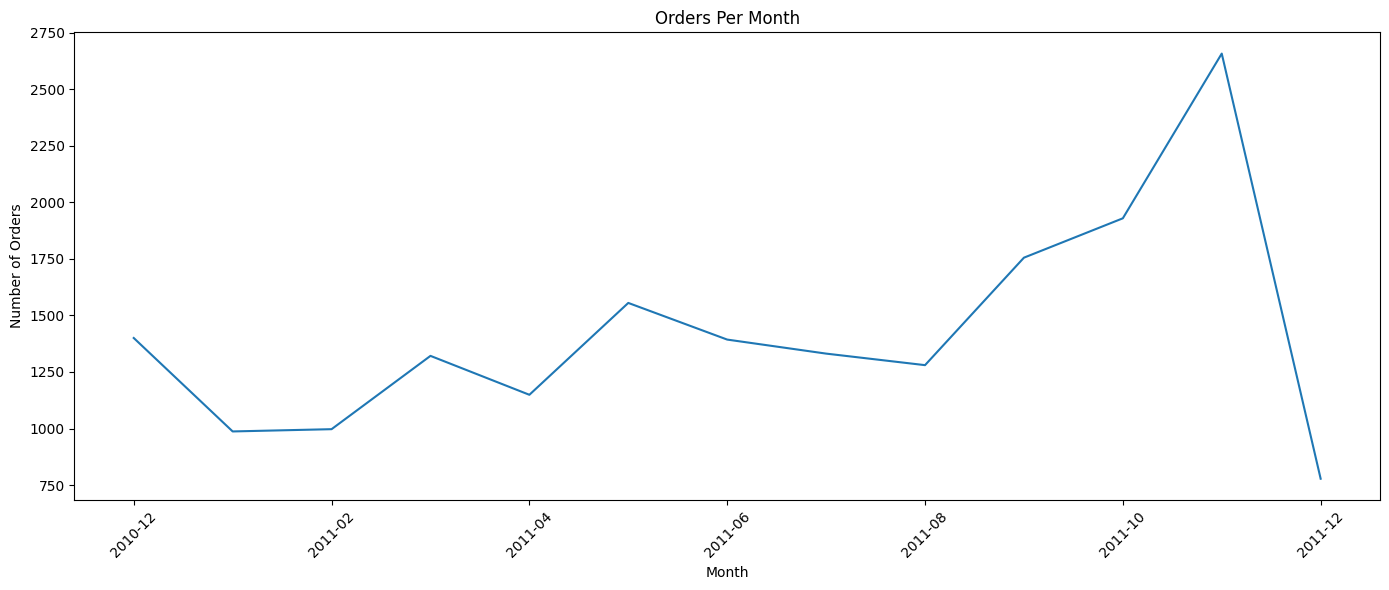


===== BUSINESS INSIGHTS =====

1. Identify highest-value customers.
2. Determine best-selling products.
3. Analyze country-wise revenue.
4. Study monthly sales trends.
5. Understand customer spending behavior.
6. Explore customer segmentation.

PROJECT COMPLETED SUCCESSFULLY!


In [5]:
# ==========================================
# ECOMMERCE CUSTOMER ANALYTICS PROJECT
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ------------------------------------------
# Create folders
# ------------------------------------------

os.makedirs("charts", exist_ok=True)
os.makedirs("output", exist_ok=True)

# ------------------------------------------
# Load Dataset
# ------------------------------------------

df = pd.read_excel("Online Retail.xlsx")

print("\n===== DATASET INFO =====\n")
print(df.info())

print("\n===== FIRST 5 ROWS =====\n")
print(df.head())

# ------------------------------------------
# Data Cleaning
# ------------------------------------------

df = df.dropna(subset=["CustomerID"])

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Remove returns and negative values

df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
]

# ------------------------------------------
# Save Cleaned Dataset
# ------------------------------------------

df.to_csv(
    "output/cleaned_ecommerce_data.csv",
    index=False
)

# ==========================================
# 1. TOP 10 CUSTOMERS
# ==========================================

top_customers = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")

plt.xlabel("Customer ID")

plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(
    "charts/top_customers.png"
)

plt.show()

# ==========================================
# 2. TOP 10 PRODUCTS
# ==========================================

top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")

plt.xlabel("Product")

plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(
    "charts/top_products.png"
)

plt.show()

# ==========================================
# 3. COUNTRY SALES
# ==========================================

country_sales = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

country_sales.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")

plt.xlabel("Country")

plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(
    "charts/country_sales.png"
)

plt.show()

# ==========================================
# 4. MONTHLY SALES TREND
# ==========================================

monthly_sales = (
    df.groupby(
        df["InvoiceDate"].dt.to_period("M")
    )["Revenue"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "charts/monthly_sales_trend.png"
)

plt.show()

# ==========================================
# 5. ORDER VALUE DISTRIBUTION
# ==========================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["Revenue"],
    bins=50,
    kde=True
)

plt.title("Revenue Distribution")

plt.tight_layout()

plt.savefig(
    "charts/revenue_distribution.png"
)

plt.show()

# ==========================================
# 6. CUSTOMER SEGMENTATION
# ==========================================

customer_revenue = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
)

plt.figure(figsize=(10,5))

sns.histplot(
    customer_revenue,
    bins=30,
    kde=True
)

plt.title("Customer Revenue Distribution")

plt.tight_layout()

plt.savefig(
    "charts/customer_segmentation.png"
)

plt.show()

# ==========================================
# 7. ORDERS BY MONTH
# ==========================================

orders_per_month = (
    df.groupby(
        df["InvoiceDate"].dt.to_period("M")
    )["InvoiceNo"]
    .nunique()
)

orders_per_month.index = (
    orders_per_month.index.astype(str)
)

plt.figure(figsize=(14,6))

orders_per_month.plot()

plt.title("Orders Per Month")

plt.xlabel("Month")

plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "charts/order_distribution.png"
)

plt.show()

# ==========================================
# BUSINESS INSIGHTS
# ==========================================

print("\n===== BUSINESS INSIGHTS =====\n")

print("1. Identify highest-value customers.")

print("2. Determine best-selling products.")

print("3. Analyze country-wise revenue.")

print("4. Study monthly sales trends.")

print("5. Understand customer spending behavior.")

print("6. Explore customer segmentation.")

print("\nPROJECT COMPLETED SUCCESSFULLY!")